In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

In [16]:
df = pd.read_csv('Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [17]:
df_cleaned = df.drop(['Channel', 'Region'], axis='columns')

In [18]:
scaler = StandardScaler()
df_cleaned_scaled = scaler.fit_transform(df_cleaned)

In [19]:
kmeans_model = KMeans(n_clusters=3, n_init='auto', random_state=36)

In [20]:
kmeans_model.fit(df_cleaned_scaled)
clusters = kmeans_model.labels_
df['Clusters'] = clusters
df


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clusters
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0
...,...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204,0
436,1,3,39228,1431,764,4510,93,2346,0
437,2,3,14531,15488,30243,437,14841,1867,2
438,1,3,10290,1981,2232,1038,168,2125,0


In [21]:
score = silhouette_score(df_cleaned_scaled, clusters, random_state=36)
print(score)

0.33391714199926514


In [22]:
df.groupby('Clusters').mean().round(2)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Clusters,,,,,,,,
0,1.12,2.54,13618.91,3143.09,3881.77,3471.05,854.93,1192.14
1,1.85,2.62,25770.77,35160.38,41977.38,6844.54,19867.38,7880.31
2,1.85,2.55,5635.77,10034.58,15765.62,1457.59,6768.01,1737.61


# Finding the best Number of clusters

In [23]:
k = range(2, 11)
scores = []

for i in k:
    kmeans_model = KMeans(n_clusters=i, n_init='auto', random_state=36).fit(df_cleaned_scaled)
    clusters = kmeans_model.labels_
    silhouette_s = silhouette_score(df_cleaned_scaled, clusters)
    
    scores.append(silhouette_s)
    print(f'Current iteration index score is: K{i} = {scores[i-2]}')


Current iteration index score is: K2 = 0.5532526964184259
Current iteration index score is: K3 = 0.33391714199926514
Current iteration index score is: K4 = 0.3464639277919304
Current iteration index score is: K5 = 0.35701115043244896
Current iteration index score is: K6 = 0.31461520620844025
Current iteration index score is: K7 = 0.31507176368724626
Current iteration index score is: K8 = 0.28057906125661214
Current iteration index score is: K9 = 0.28825098082163936
Current iteration index score is: K10 = 0.292086178186841


In [31]:

kmeans_model = KMeans(n_clusters=k[np.argmax(scores)], n_init='auto', random_state=36).fit(df_cleaned_scaled)

clusters = kmeans_model.labels_

df['Clusters'] = clusters

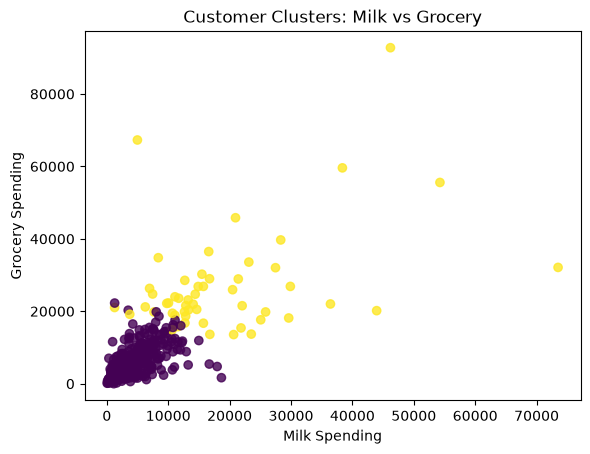

In [39]:


plt.scatter(
    df['Milk'],
    df['Grocery'],
    c=df['Clusters'],
    alpha=0.8
)

plt.xlabel('Milk Spending')
plt.ylabel('Grocery Spending')
plt.title('Customer Clusters: Milk vs Grocery')

plt.show()

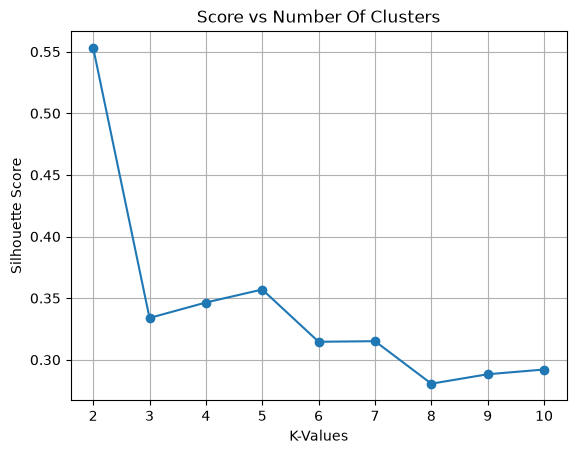

In [ ]:
plt.plot(k, scores, marker='o')
plt.xlabel('K-Values')
plt.ylabel('Silhouette Score')
plt.title('Score vs Number Of Clusters')
plt.grid(True)

In [ ]:
#? It looks like the model clustered customers that spend more money and spend less money into\
    # seperate groups.

df.groupby('Clusters')[
    [
        'Fresh',
        'Milk',
        'Grocery',
        'Frozen',
        'Detergents_Paper',
        'Delicassen'
    ]
].mean().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Clusters,,,,,,
0,12111.31,3975.64,5354.67,2917.14,1653.18,1245.55
1,11189.70,19090.26,26911.40,4202.17,11850.47,3564.43
